# Caso d'uso: Classificazione di Specie di Fiori con SVM

ITS Apulia Digital Academy - ML per il Mondo del Lavoro

Il dataset `iris` di scikit-learn contiene misure di sepali e petali di
fiori. In questo notebook costruiamo una pipeline completa per
classificare tre specie di iris (*setosa*, *versicolor*, *virginica*)
con una SVM a kernel RBF, e poi cerchiamo i migliori iperparametri con
`GridSearchCV`.

---

## 1. Import e caricamento del dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Il dataset iris e' gia incluso in scikit-learn: 150 fiori, 4 feature,
# 3 specie (setosa, versicolor, virginica)
dati = load_iris()
X = dati.data
y = dati.target

print("Numero di fiori:", X.shape[0])
print("Numero di feature per fiore:", X.shape[1])
print("Nomi delle feature:", dati.feature_names)
print("Specie da classificare:", list(dati.target_names))

Numero di fiori: 150
Numero di feature per fiore: 4
Nomi delle feature: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Specie da classificare: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


## 2. Split train/test e standardizzazione

Dividiamo i dati in training e test set, poi standardizziamo le feature.
Le SVM sono sensibili alla scala: senza standardizzazione, una feature
con valori grandi peserebbe piu delle altre nel calcolo delle distanze.

In [ ]:
# stratify=y mantiene le stesse proporzioni di specie in train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Lo scaler viene "fittato" solo sul training set, per evitare data leakage
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit solo sul train per l' addestramento
X_test_s = scaler.transform(X_test)          # solo transform, riusando i parametri del train

print("Esempi nel training set:", X_train_s.shape[0])
print("Esempi nel test set:", X_test_s.shape[0])

Esempi nel training set: 120
Esempi nel test set: 30


## 3. Matrice di confusione

La matrice di confusione mostra, per ogni specie vera, quante volte il
modello ha predetto correttamente e con quali specie si e confuso.

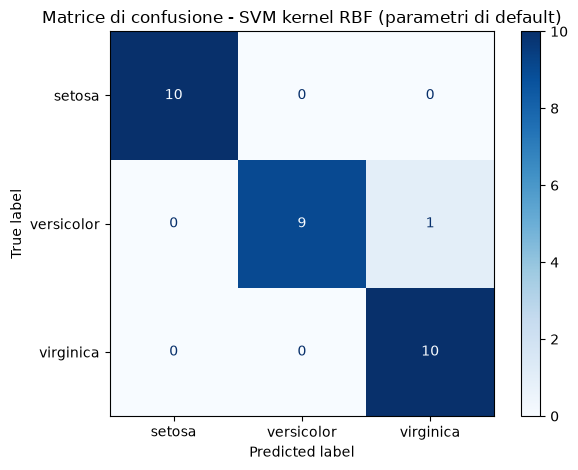

Accuracy sul test set: 0.967



In [14]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=dati.target_names, cmap="Blues")
plt.title("Matrice di confusione - SVM kernel RBF (parametri di default)")
plt.tight_layout()
plt.show()

print(f"Accuracy sul test set: {accuracy:.3f}\n")

## 4. Tuning con GridSearchCV

Proviamo diverse combinazioni di `C` e `gamma` e scegliamo quella con
la migliore accuracy media in cross-validation (non sul test set, che
resta da parte per la valutazione finale).

In [ ]:
# ----------------------------------------------------------------
# 5. Tuning con GridSearchCV
# ----------------------------------------------------------------

# Griglia di iperparametri: verranno provate tutte le combinazioni
# possibili tra i valori di C e di gamma (4 x 4 = 16 combinazioni)
griglia = {
    "C": [0.1, 1, 10, 100],
    "gamma": [0.01, 0.1, 1, "scale"], #scale permette a sklearn di calcoalre in autonomia il numero da inserire in quella posizione in base agli altri dati

    #C → quanto il modello tollera errori di classificazione (indipendente dal kernel)
    #gamma→ quanto è flessibile il confine tracciato dal kernel RBF (specifico di RBF, non esiste per il kernel lineare)
}

# Per ogni combinazione, GridSearchCV allena e valuta il modello con
# 5-fold cross-validation, poi tiene quella con l'accuracy media migliore
ricerca = GridSearchCV(SVC(kernel="rbf"), griglia, cv=5, scoring="accuracy")
ricerca.fit(X_train_s, y_train)

print("Migliori iperparametri:", ricerca.best_params_)
print(f"Accuracy media in cross-validation: {ricerca.best_score_:.3f}")

Migliori iperparametri: {'C': 1, 'gamma': 0.1}
Accuracy media in cross-validation: 0.983


## 5. Valutazione finale del modello ottimizzato

Confrontiamo il modello di default con quello ottimizzato, valutando
entrambi sullo stesso test set.

Accuracy modello di default:   0.967
Accuracy modello ottimizzato:  0.967


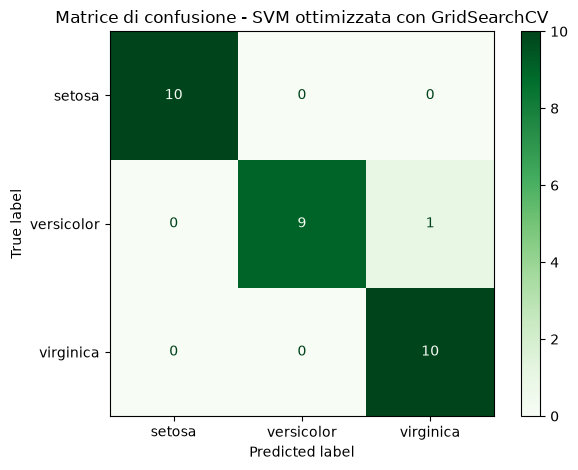

Le predizioni dei due modelli sono identiche: True
Iperparametri modello default: C=1.0, gamma='scale' (valori di default di SVC)
Iperparametri modello ottimizzato: {'C': 1, 'gamma': 0.1}


In [13]:
# ricerca.best_estimator_ e' gia il modello riallenato con i parametri migliori
migliore_modello = ricerca.best_estimator_
y_pred_ottimizzato = migliore_modello.predict(X_test_s)
accuracy_ottimizzata = accuracy_score(y_test, y_pred_ottimizzato)

print(f"Accuracy modello di default:   {accuracy:.3f}")
print(f"Accuracy modello ottimizzato:  {accuracy_ottimizzata:.3f}")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ottimizzato, display_labels=dati.target_names, cmap="Greens")
plt.title("Matrice di confusione - SVM ottimizzata con GridSearchCV")
plt.tight_layout()
plt.show()

# Confrontiamo le predizioni dei due modelli fiore per fiore
predizioni_uguali = (y_pred == y_pred_ottimizzato).all()
print("Le predizioni dei due modelli sono identiche:", predizioni_uguali)

# Se sono identiche, il tuning non ha cambiato nulla su QUESTO test set,
# pur avendo trovato iperparametri leggermente diversi
print("Iperparametri modello default: C=1.0, gamma='scale' (valori di default di SVC)")
print("Iperparametri modello ottimizzato:", ricerca.best_params_)

## Conclusioni

### Non è l'unica scelta valida

Su questo specifico dataset, altri modelli che abbiamo visto nel corso darebbero risultati molto simili:

| Modello | Come si comporterebbe su Iris |
|---|---|
| **KNN** | Probabilmente accuracy comparabile — Iris e' un dataset "da manuale" anche per KNN |
| **Regressione logistica** | Buona, ma faticherebbe leggermente di piu sul confine versicolor/virginica (non lineare) |
| **Alberi decisionali / Random Forest** | Anche loro molto efficaci, spesso usati proprio come alternativa didattica a Iris |

Iris e' un dataset talmente "pulito" e piccolo che quasi ogni classificatore ragionevole raggiunge il 90-97% di accuracy — non e' un caso in cui la SVM ha un vantaggio drammatico.

### Quando la SVM diventa davvero la scelta migliore

Il vantaggio reale della SVM emerge in contesti diversi da Iris, ad esempio nel caso della rilevazione di phishing:

- **Alta dimensionalita** (migliaia di feature, es. testo) — li' la SVM batte spesso KNN e alberi
- **Pochi esempi rispetto al numero di feature** — regime dove la SVM e' piu